# A diagnostic classifier: thinking like a clinician

In medicine, "93% accurate" is close to meaningless. What matters is *which*
mistakes a test makes. Missing a cancer (a false negative) and sending a
healthy patient for a biopsy (a false positive) have very different costs,
and a good model is one tuned for the right trade-off.

This notebook builds a classifier on **real data**: the Wisconsin Diagnostic
Breast Cancer dataset, which ships with scikit-learn. Each of its 569 rows
describes cell nuclei measured from a digitised image of a fine-needle
biopsy, labelled malignant or benign. We'll cover:

1. The data and its limits
2. Sensitivity, specificity and why accuracy misleads
3. Comparing models with cross-validation
4. Choosing a threshold for screening vs. confirmation
5. Whether the predicted probabilities can be trusted

This is a learning exercise, not a medical tool.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.calibration import calibration_curve
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

plt.rcParams.update({"figure.figsize": (9, 4), "axes.spines.top": False, "axes.spines.right": False})

raw = load_breast_cancer(as_frame=True)
X = raw.data
y = (raw.target == 0).astype(int)  # scikit-learn codes malignant as 0; we want "1 = malignant"
y.name = "malignant"
print(f"{len(X)} biopsies, {X.shape[1]} measurements each, {y.mean():.0%} malignant")
X.iloc[:, :6].head()

569 biopsies, 30 measurements each, 37% malignant


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness
0,17.99,10.38,122.80,1001.0,0.11840,0.27760
1,20.57,17.77,132.90,1326.0,0.08474,0.07864
2,19.69,21.25,130.00,1203.0,0.10960,0.15990
3,11.42,20.38,77.58,386.1,0.14250,0.28390
4,20.29,14.34,135.10,1297.0,0.10030,0.13280


## 1. The data and its limits

The 30 columns are ten measurements of the cell nuclei (radius, texture,
smoothness and so on), each summarised three ways: the mean, the standard
error, and the "worst" (largest) value in the image.

Worth saying before we start, because it applies to most medical datasets:

- **It's small.** 569 patients is enough to learn from, not enough to trust
  in a clinic.
- **It's from one place and one time.** A model trained here may not work on
  images from a different hospital, microscope or population.
- **It's not a screening population.** 37% malignant is far higher than in
  general screening, where cancers are rare. That changes what a positive
  result means (see section 4).

In [ ]:
by_class = X.groupby(y)[["mean radius", "mean concave points", "worst area", "mean texture"]].median().T
by_class.columns = ["benign", "malignant"]
by_class.round(3)

,benign,malignant
mean radius,12.200,17.325
mean concave points,0.023,0.086
worst area,547.400,1303.000
mean texture,17.390,21.460


Malignant nuclei are larger and more irregular (more "concave points" in
their outline). That's in line with what pathologists look for, which is
reassuring: the model has real biology to learn from.

## 2. Accuracy hides the mistakes that matter

Two numbers describe a diagnostic test far better than accuracy:

- **Sensitivity** (recall): of patients who *have* cancer, how many does it catch?
- **Specificity:** of patients who *don't*, how many does it correctly clear?

A test that calls everyone benign is 63% "accurate" here and catches zero
cancers. That's why accuracy alone is never reported for a medical test.

In [ ]:
def describe(y_true, y_pred, label):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    print(f"{label}")
    print(f"  accuracy {(tp + tn) / len(y_true):.1%}   sensitivity {tp / (tp + fn):.1%}   "
          f"specificity {tn / (tn + fp):.1%}")
    print(f"  missed cancers (false negatives): {fn}   unnecessary follow-ups (false positives): {fp}")


describe(y, np.zeros_like(y), "Always say 'benign'")

Always say 'benign'
  accuracy 62.7%   sensitivity 0.0%   specificity 100.0%
  missed cancers (false negatives): 212   unnecessary follow-ups (false positives): 0


## 3. Comparing models

We compare a simple model (logistic regression) with a flexible one (random
forest). First we lock away 25% of patients as a final test set, to check
the chosen model once at the very end.

With so few patients, a single split of the rest would be noisy, so we use
**cross-validated predictions**: every patient in the development set is
predicted by a model that never saw them, and we score all those
predictions together.

Logistic regression  cross-validated ROC AUC 0.992
  at the default 0.5 threshold:
  accuracy 97.7%   sensitivity 96.2%   specificity 98.5%
  missed cancers (false negatives): 6   unnecessary follow-ups (false positives): 4


Random forest        cross-validated ROC AUC 0.990
  at the default 0.5 threshold:
  accuracy 94.6%   sensitivity 91.8%   specificity 96.3%
  missed cancers (false negatives): 13   unnecessary follow-ups (false positives): 10


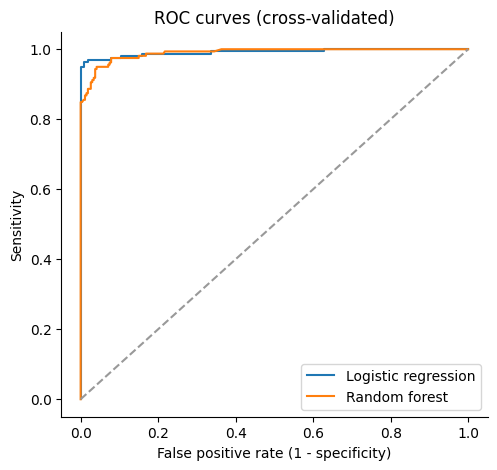

In [ ]:
X_dev, X_test, y_dev, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=0)
folds = StratifiedKFold(5, shuffle=True, random_state=0)
models = {
    "Logistic regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)),
    "Random forest": RandomForestClassifier(n_estimators=400, random_state=0),
}
cv_probs = {}
for name, model in models.items():
    cv_probs[name] = cross_val_predict(model, X_dev, y_dev, cv=folds, method="predict_proba")[:, 1]
    print(f"{name:<20} cross-validated ROC AUC {roc_auc_score(y_dev, cv_probs[name]):.3f}")
    describe(y_dev, (cv_probs[name] >= 0.5).astype(int), "  at the default 0.5 threshold:")

fig, ax = plt.subplots(figsize=(5.5, 5))
for name, probs in cv_probs.items():
    fpr, tpr, _ = roc_curve(y_dev, probs)
    ax.plot(fpr, tpr, label=name)
ax.plot([0, 1], [0, 1], "--", color="#999")
ax.set(title="ROC curves (cross-validated)", xlabel="False positive rate (1 - specificity)",
       ylabel="Sensitivity")
ax.legend();

Both models are strong, and logistic regression is at least as good as the
random forest. When a simple, explainable model matches a complex one, choose
the simple one. In medicine that matters even more: clinicians need to
understand *why* a model flags a patient.

## 4. Choosing the threshold

The model outputs a probability of malignancy. Where we draw the line
depends on what the test is *for*:

- **Screening** (deciding who gets a closer look): a missed cancer is far
  worse than an extra follow-up, so we want very high sensitivity, even at
  the cost of more false positives.
- **Confirmation** (deciding who gets aggressive treatment): a false positive
  is now costly too, so we want high specificity as well.

In [ ]:
probs = cv_probs["Logistic regression"]
rows = []
for t in [0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.9]:
    tn, fp, fn, tp = confusion_matrix(y_dev, (probs >= t).astype(int)).ravel()
    rows.append({"threshold": t, "sensitivity": tp / (tp + fn), "specificity": tn / (tn + fp),
                 "missed cancers": fn, "false positives": fp})
table = pd.DataFrame(rows)
print(table.to_string(index=False, formatters={"sensitivity": "{:.1%}".format, "specificity": "{:.1%}".format}))

 threshold sensitivity specificity  missed cancers  false positives
      0.05       98.7%       83.9%               2               43
      0.10       97.5%       89.5%               4               28
      0.20       96.9%       95.5%               5               12
      0.30       96.9%       97.0%               5                8
      0.50       96.2%       98.5%               6                4
      0.70       93.1%      100.0%              11                0
      0.90       86.2%      100.0%              22                0


Lowering the threshold catches more cancers and sends more healthy patients
for follow-up. There's no free lunch: the right point is a clinical decision
about relative harms, made with doctors and patients, not chosen by the data
scientist.

For a screening use we'll pick the highest threshold that still catches at
least 98% of cancers in cross-validation, then check it on the untouched
test set.

In [ ]:
for t in np.linspace(0.9, 0.01, 90):
    sensitivity = ((probs >= t) & (y_dev == 1)).sum() / (y_dev == 1).sum()
    if sensitivity >= 0.98:
        screening_threshold = t
        break
print(f"Screening threshold chosen on development data: {screening_threshold:.2f}\n")

final = models["Logistic regression"].fit(X_dev, y_dev)
test_probs = final.predict_proba(X_test)[:, 1]
describe(y_test, (test_probs >= 0.5).astype(int), "Held-out test set, default 0.5 threshold")
describe(y_test, (test_probs >= screening_threshold).astype(int),
         f"Held-out test set, screening threshold {screening_threshold:.2f}")

Screening threshold chosen on development data: 0.09

Held-out test set, default 0.5 threshold
  accuracy 98.6%   sensitivity 96.2%   specificity 100.0%
  missed cancers (false negatives): 2   unnecessary follow-ups (false positives): 0
Held-out test set, screening threshold 0.09
  accuracy 91.6%   sensitivity 100.0%   specificity 86.7%
  missed cancers (false negatives): 0   unnecessary follow-ups (false positives): 12


On patients it has never seen, the screening threshold trades a dozen extra
follow-ups for fewer missed cancers, which is the trade we asked for.

**What a positive result means depends on how common the disease is.** In
this dataset 37% of biopsies are malignant, so a positive result is usually
right. In a screening population where perhaps 1% have cancer, the same
sensitivity and specificity would produce mostly false positives. The
calculation below shows it.

In [ ]:
tn, fp, fn, tp = confusion_matrix(y_test, (test_probs >= screening_threshold).astype(int)).ravel()
sens, spec = tp / (tp + fn), tn / (tn + fp)
for prevalence in [0.37, 0.10, 0.01]:
    ppv = sens * prevalence / (sens * prevalence + (1 - spec) * (1 - prevalence))
    print(f"If {prevalence:>4.0%} of patients have cancer, a positive result is right {ppv:.0%} of the time")

If  37% of patients have cancer, a positive result is right 81% of the time
If  10% of patients have cancer, a positive result is right 45% of the time
If   1% of patients have cancer, a positive result is right 7% of the time


## 5. Can the probabilities be trusted?

If the model says "70% chance of malignancy", about 70% of such patients
should actually have cancer. A **calibration curve** checks this. It matters
whenever a probability is shown to a clinician, rather than just a yes/no.

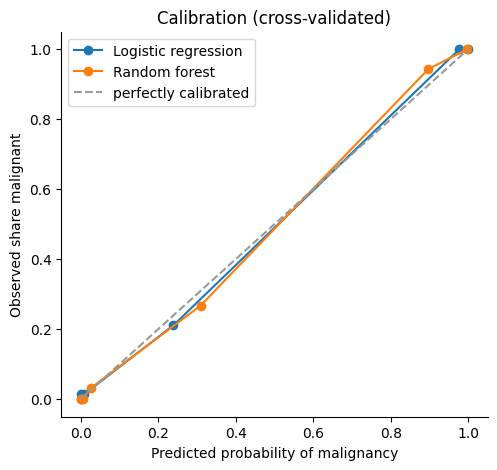

In [ ]:
fig, ax = plt.subplots(figsize=(5.5, 5))
for name, p in cv_probs.items():
    observed, predicted = calibration_curve(y_dev, p, n_bins=6, strategy="quantile")
    ax.plot(predicted, observed, "o-", label=name)
ax.plot([0, 1], [0, 1], "--", color="#999", label="perfectly calibrated")
ax.set(title="Calibration (cross-validated)", xlabel="Predicted probability of malignancy",
       ylabel="Observed share malignant")
ax.legend();

Points near the diagonal mean the probabilities are honest, and both models
are well calibrated here. Notice how few points sit in the middle: most
biopsies are clear-cut, so the model is usually confident either way, and
the middle of the curve rests on few patients. On harder problems
calibration is often worse; a model that ranks patients well but gives
poor probabilities can be fixed with scikit-learn's `CalibratedClassifierCV`.

## Takeaways

- Report sensitivity and specificity, never accuracy alone.
- With small medical datasets, use cross-validation to compare models.
- Prefer the simpler model when it performs as well; explainability matters.
- The threshold is a clinical decision about which mistake is worse.
- What a positive result means depends on how common the disease is.
- A model from one hospital's data needs testing elsewhere before anyone relies on it.